In [6]:
import pandas as pd
import numpy as np

In [7]:
# load the dataset to notebook
df =pd.read_csv("bank.csv")

In [5]:
#to view the dataset
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [7]:
df.shape

(11162, 17)

In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [10]:
#checking the misssing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
month        0.0
duration     0.0
campaign     0.0
pdays        0.0
previous     0.0
poutcome     0.0
deposit      0.0
dtype: float64

In [12]:
# checking duplicates 
df.duplicated().sum()

np.int64(0)

In [13]:
#check the unique values
for col in df.select_dtypes(include= "object"):
    print(col)
    print(df[col].unique())
    print("____________")

job
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
____________
marital
['married' 'single' 'divorced']
____________
education
['secondary' 'tertiary' 'primary' 'unknown']
____________
default
['no' 'yes']
____________
housing
['yes' 'no']
____________
loan
['no' 'yes']
____________
contact
['unknown' 'cellular' 'telephone']
____________
month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
____________
poutcome
['unknown' 'other' 'failure' 'success']
____________
deposit
['yes' 'no']
____________


In [14]:
# checking numerical summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [17]:
# create age groups 
bins =[18,30,40,50,60,100]
labels=["18-30","31-40","41-50","51-60","60+"]
df["age_group"]= pd.cut(df["age"],bins=bins,labels=labels, include_lowest=True)

In [18]:
df["age_group"].value_counts()

age_group
31-40    4188
41-50    2496
18-30    2007
51-60    1860
60+       611
Name: count, dtype: int64

In [19]:
# save the cleaned dataset
df.to_csv("Bank_cleaned.csv",index =False)

PermissionError: [Errno 13] Permission denied: 'Bank_cleaned.csv'

In [ ]:
df['age_group'].isnull().sum()

### Exploratory Data analysis


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

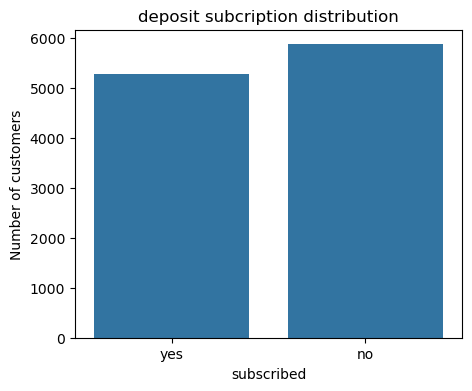

In [8]:
# How many customers subscribed to the term deposit?
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='deposit')
plt.title("deposit subcription distribution")
plt.xlabel("subscribed")
plt.ylabel("Number of customers")

plt.show()

##### Observation
- The number of customers who did not subscribe to a term deposit is slightly higher than those who subscribed.
- The target variable is fairly balanced, although the "No" class has a larger share.
- This suggests that convincing customers to subscribe remains a challenge, highlighting the need for targeted marketing strategies.

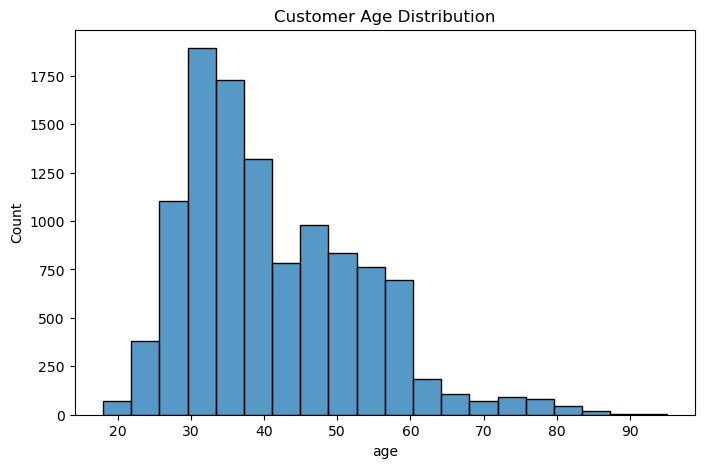

In [9]:
# Age distribution
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20)
plt.title("Customer Age Distribution")

plt.show()

##### Observation
- Most customers are between 30 and 45 years of age.
- The customer count gradually decreases after age 50.
- Very young (<25) and elderly (>70) customers represent only a small portion of the customer base.

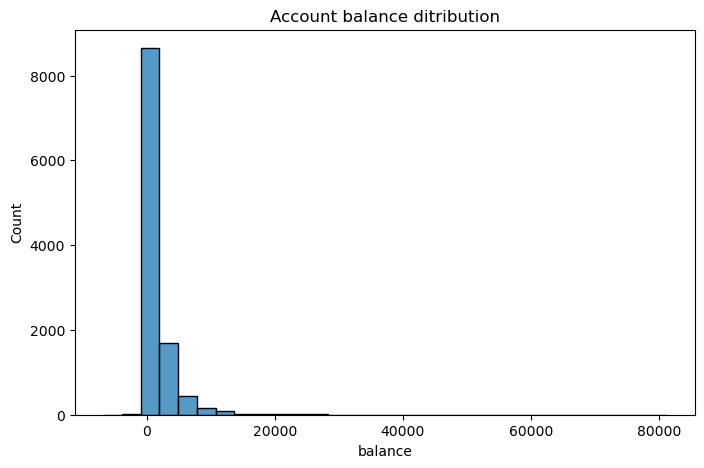

In [10]:
# balanced distribution 
plt.figure(figsize=(8,5))

sns.histplot(df['balance'], bins=30)
plt.title("Account balance ditribution")
plt.show()

##### Observation
- Most customers maintain low account balances.
- The distribution is highly right-skewed, with a small number of customers holding very large balances.
- These high-balance customers appear to be genuine observations rather than data errors and may represent high-value customers. 

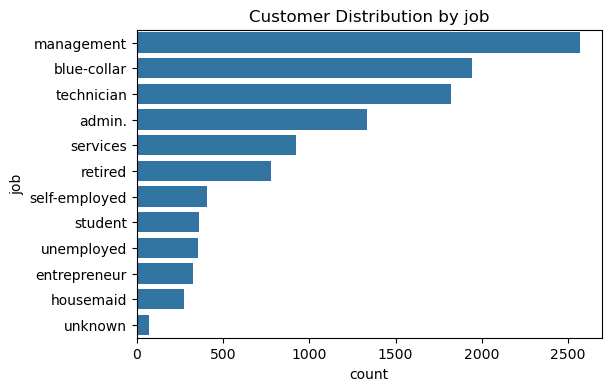

In [11]:
# job distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, y='job', order=df['job'].value_counts().index)
plt.title("Customer Distribution by job")
plt.show()

##### Observation
- Management is the largest customer group.
- Blue-collar and Technician occupations also represent a significant share of customers.
- The Unknown job category has the fewest customers.

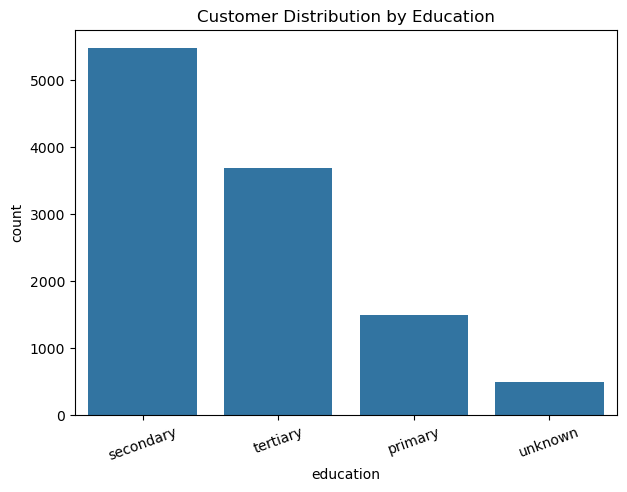

In [12]:
# Education Distribution 
plt.figure(figsize=(7,5))

sns.countplot(data = df, x='education', order =df['education'].value_counts().index)

plt.title("Customer Distribution by Education")
plt.xticks(rotation = 20)
plt.show()

##### Observation
- Most customers have secondary education.
- Customers with tertiary education form the second-largest group.
- Only a small percentage of customers have an unknown education level.

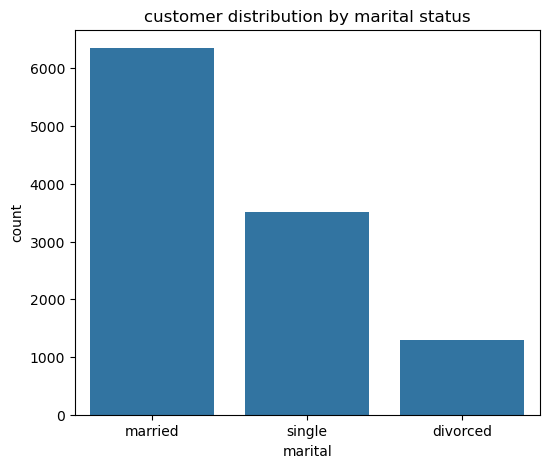

In [13]:
# marital Status 
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='marital')

plt.title("customer distribution by marital status")
plt.show()

##### Observation
- Married customers make up the majority of the customer base.
- Single customers represent the second-largest group.
- Divorced customers account for the smallest proportion.

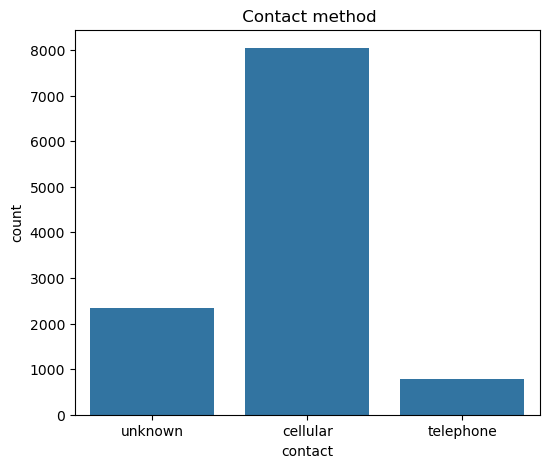

In [14]:
# contact method 
plt.figure(figsize=(6,5))
sns.countplot(data =df, x= "contact")
plt.title(" Contact method")

plt.show()

##### Observation
- The cellular contact method is used for the majority of marketing campaigns.
- Telephone is used much less frequently.
- A notable number of records have the contact method marked as unknown.

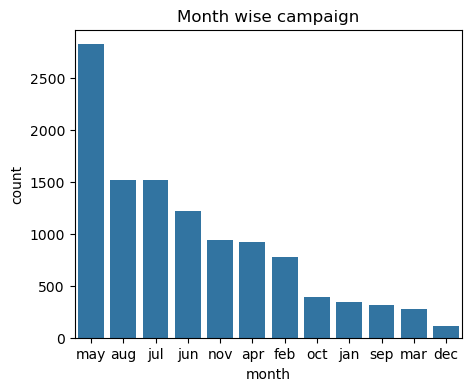

In [15]:
# month wise campaign
plt.figure(figsize=(5,4))
sns.countplot(data=df , x= "month",order=df["month"].value_counts().index)
plt.title("Month wise campaign")

plt.show()

##### Observation
- Most marketing contacts occurred during May.
- Campaign activity gradually declined after May.
- Very few campaigns were conducted in December, indicating possible seasonal variation in marketing efforts. 

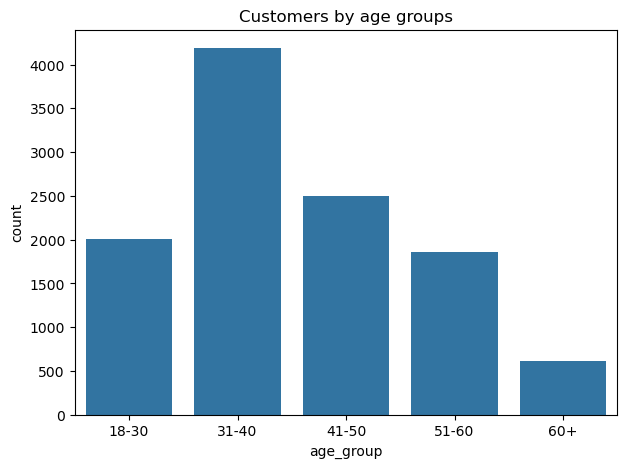

In [20]:
# Age group 
plt.figure(figsize=(7,5))

sns.countplot(data = df, x ='age_group')
plt.title("Customers by age groups")
plt.show()

##### Observation
- Customers aged 31–40 years represent the largest age group.
- The 41–50 age group is the second largest.
- Customers aged 60+ make up the smallest segment.

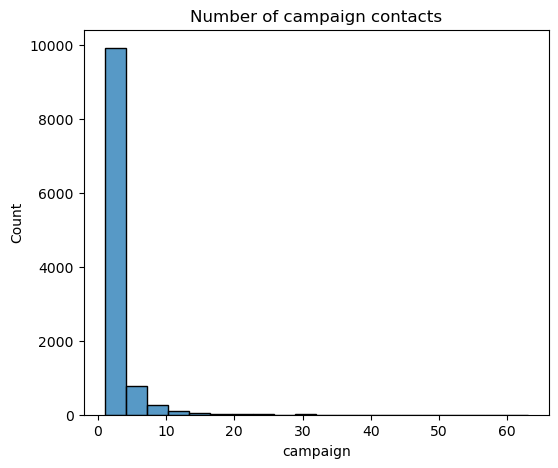

In [21]:
# campaign calls
plt.figure(figsize=(6,5))

sns.histplot(df['campaign'], bins =20)

plt.title("Number of campaign contacts")
plt.show()

##### Observation
- Most customers were contacted only one to three times.
- Very few customers received a large number of follow-up calls.
- The distribution is heavily right-skewed, suggesting the bank generally avoids excessive repeat contacts.

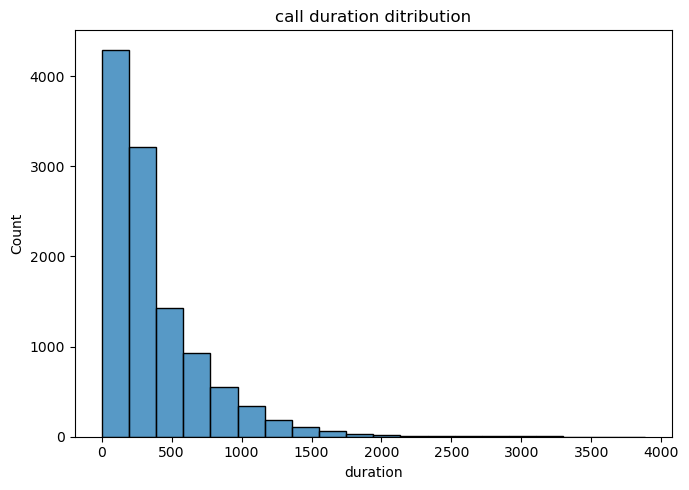

In [25]:
# call duration
plt.figure(figsize=(7,5))
sns.histplot(df["duration"],bins=20)

plt.title("call duration ditribution")
plt.tight_layout()
plt.show()

##### Observation
- Most marketing calls lasted less than 500 seconds.
- Long-duration calls are relatively rare.
- The distribution is positively skewed, indicating that only a small number of calls lasted for extended periods.

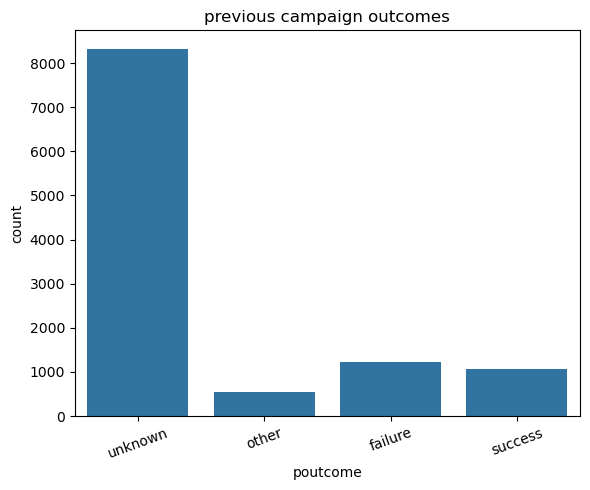

In [24]:
# prevoius campaign outcomes
plt.figure(figsize=(6,5))

sns.countplot(data =df , x='poutcome')
plt.title("previous campaign outcomes")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 

##### Observation
- The majority of customers have an unknown previous campaign outcome, likely because many had not been contacted in earlier campaigns.
- Among known outcomes, failure appears more common than success.
- This suggests that previous campaign history is unavailable for most customers.

### Bivariate Analysis

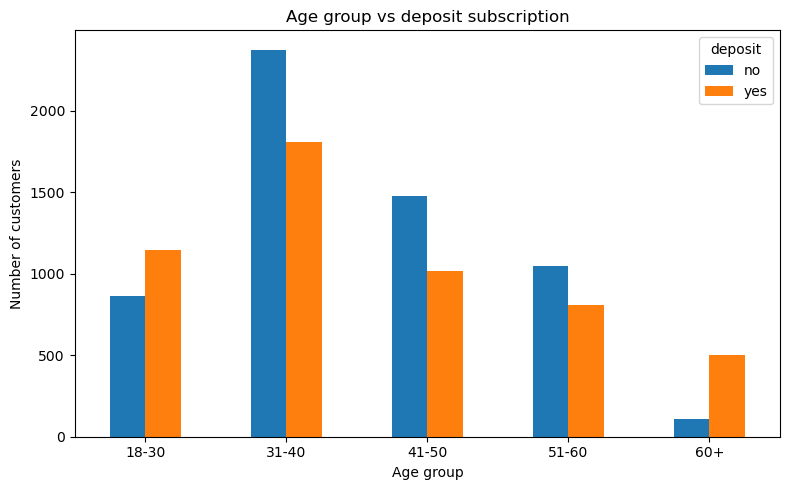

In [28]:
# Age group vs deposite subscription
# finding which age group having highest subscription rate

age_deposit=pd.crosstab(df['age_group'],df['deposit'])
age_deposit.plot(kind ="bar",figsize=(8,5))

plt.title("Age group vs deposit subscription")
plt.xlabel("Age group")
plt.ylabel("Number of customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Observation
- Customers aged 31–40 years account for the highest number of subscriptions because they are the largest customer segment.
- Customers aged 18–30 years also show strong subscription numbers relative to their group size.
- Customers aged 60+ have fewer total subscriptions due to their smaller population, but still represent a valuable niche segment.
- Marketing campaigns should primarily target customers between 31 and 50 years while maintaining personalized offers for senior customers.

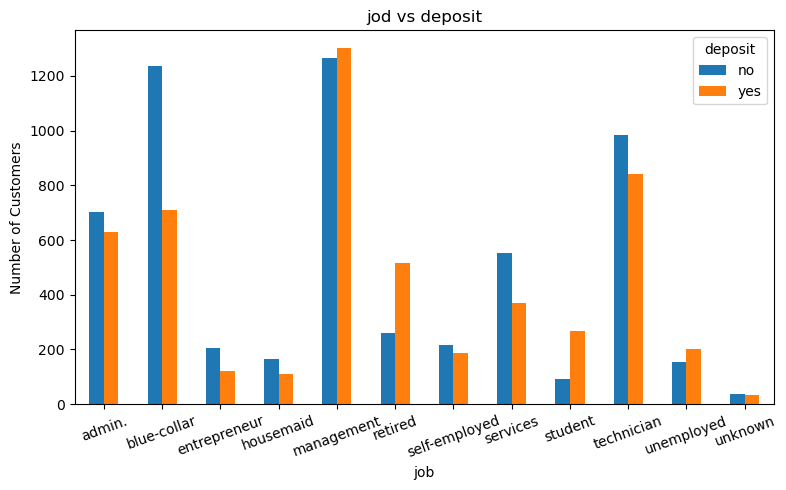

In [35]:
# which occuption as highest conversion rate ?

jod_deposit=pd.crosstab(df['job'],df['deposit'])
jod_deposit.plot(kind='bar',figsize=(8,5))

plt.title("jod vs deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### Observation
- Customers working in management, technician, and blue-collar occupations contribute the highest number of subscriptions.
- Students and retired customers appear to have relatively high subscription levels compared to their smaller customer base.
- Occupations such as unemployed and unknown contribute fewer successful subscriptions.
- Job role is an important customer segmentation variable for future campaigns.

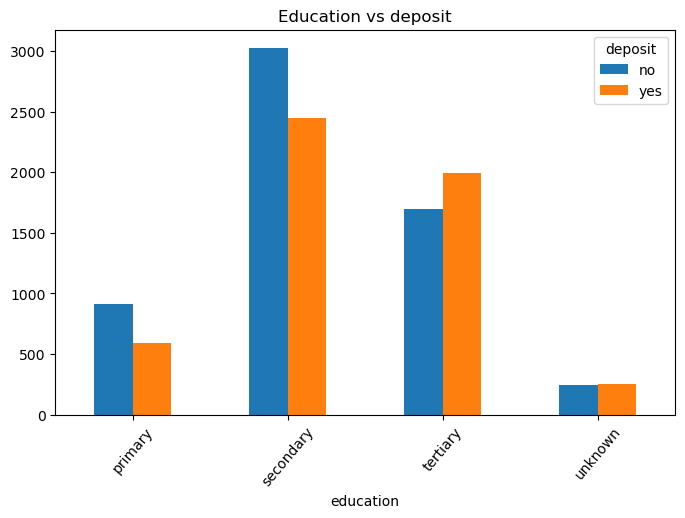

In [34]:
# which education has the better conversion rate?
edu_deposit=pd.crosstab(df['education'],df['deposit'])
edu_deposit.plot(kind="bar",figsize=(8,5))
plt.title("Education vs deposit")
plt.xticks(rotation=50)
plt.show()


##### Observation
- Customers with secondary education form the largest customer group and therefore contribute the highest number of subscriptions.
- Customers with tertiary education also show strong subscription performance.
- Customers with primary education have comparatively fewer subscriptions.
- Educational background appears to influence customer response and should be considered during campaign targeting.

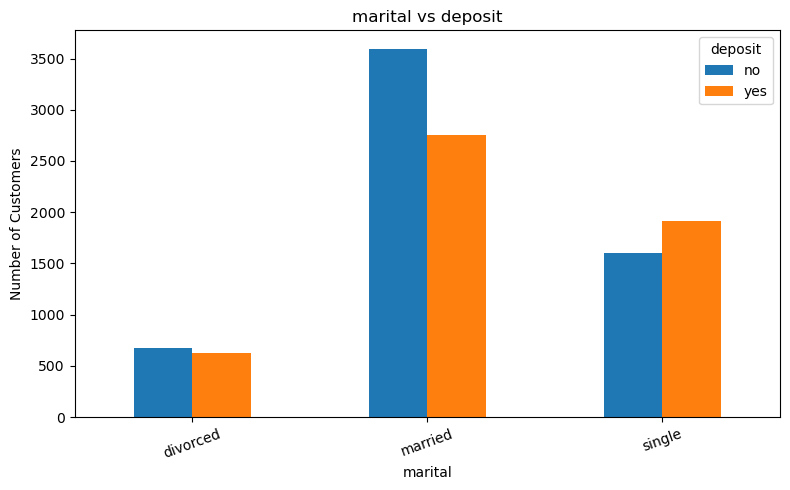

In [36]:
# which marital has the highest conversion rate?

mar_deposit=pd.crosstab(df['marital'],df['deposit'])
mar_deposit.plot(kind='bar',figsize=(8,5))

plt.title("marital vs deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### Observation
- Married customers account for the highest number of subscriptions because they represent the majority of customers.
- Single customers also respond well to marketing campaigns.
- Divorced customers contribute the fewest subscriptions due to their smaller population.
- Marketing strategies can be tailored differently for married and single customers to improve campaign effectiveness.

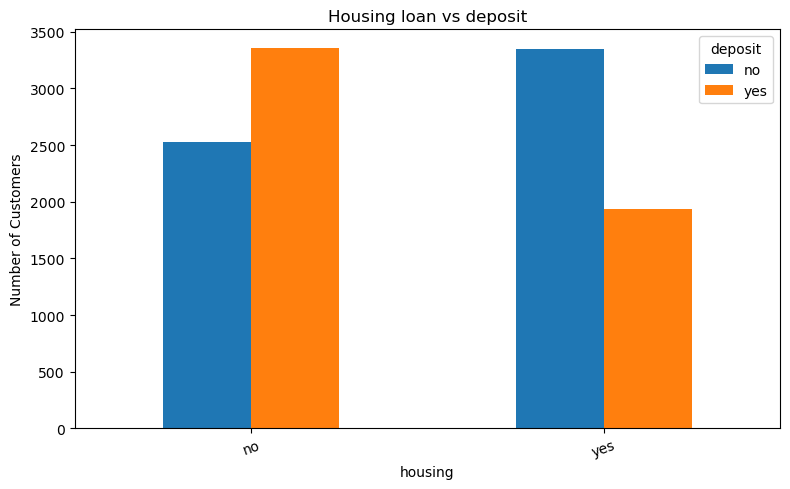

In [37]:
# is house loan effects subcription rate?

hl_deposit=pd.crosstab(df['housing'],df['deposit'])
hl_deposit.plot(kind='bar',figsize=(8,5))

plt.title("Housing loan vs deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### Observation
- Customers without housing loans subscribe to term deposits more frequently than customers with housing loans.
- Customers already paying housing loans may have less disposable income available for investment.
- Customers without housing loans represent a more promising target segment for deposit campaigns.

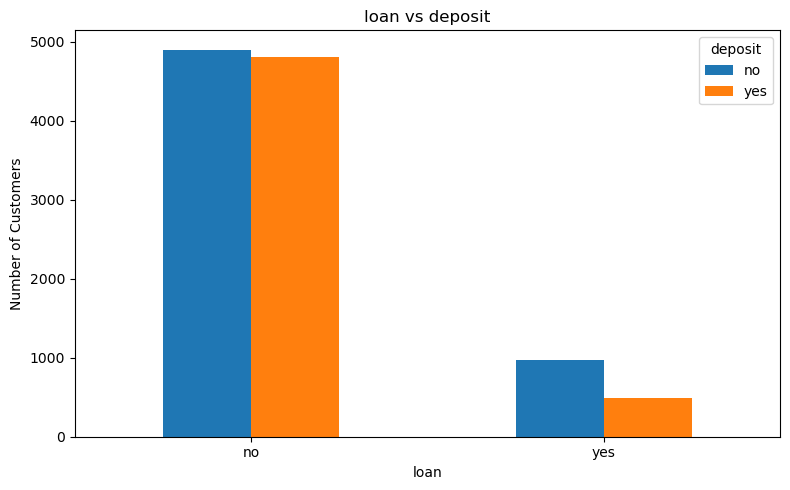

In [39]:
# is personal loan effects the subcriptions
pl_deposit=pd.crosstab(df['loan'],df['deposit'])
pl_deposit.plot(kind='bar',figsize=(8,5))

plt.title("loan vs deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Observation
- Customers without personal loans account for the majority of successful subscriptions.
- Customers with existing personal loans show noticeably fewer subscriptions.
- This suggests that loan obligations may reduce customers' willingness or ability to invest in term deposits.

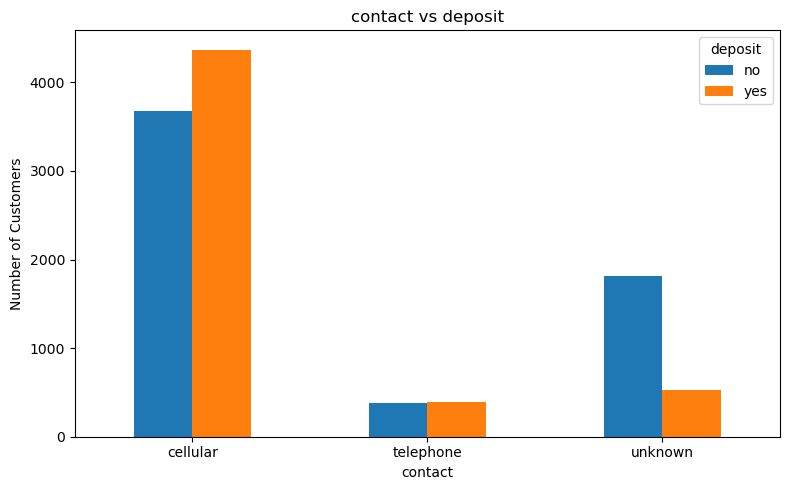

In [41]:
# identify which contact method is effective

con_deposit=pd.crosstab(df['contact'],df['deposit'])
con_deposit.plot(kind='bar',figsize=(8,5))

plt.title("contact vs deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Observation
- Cellular contact results in the highest number of successful subscriptions.
- Telephone contacts generate significantly fewer successful conversions.
- Customers with an unknown contact method show the lowest success.
- Cellular communication should remain the preferred contact channel for future campaigns.

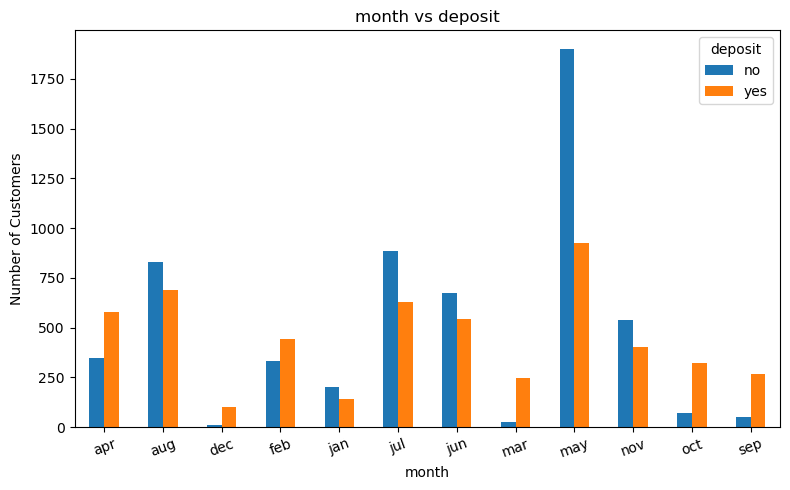

In [42]:
# which month perform best
month_deposit=pd.crosstab(df['month'],df['deposit'])
month_deposit.plot(kind='bar',figsize=(8,5))

plt.title("month vs deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### Observation
- May has the highest overall campaign activity but also records a large number of unsuccessful contacts.
- Months such as March, September, and October appear to achieve relatively stronger subscription performance compared to the number of contacts.
- Campaign effectiveness varies by month, indicating seasonal customer behavior.
- The bank should focus more on months that achieve higher conversion rates instead of simply increasing campaign volume.

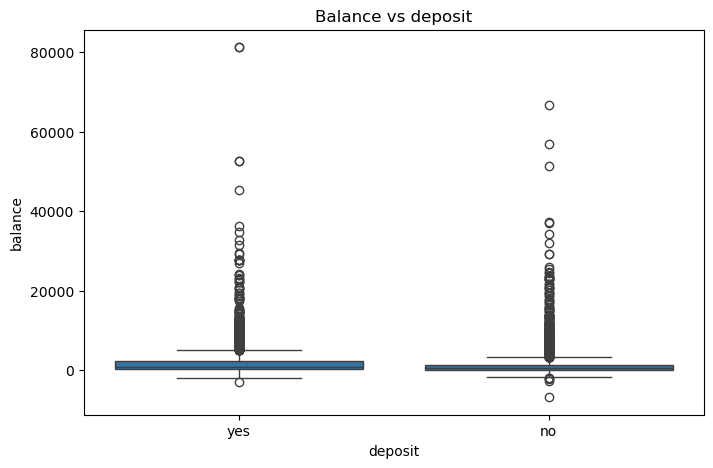

In [43]:
# checking if balance effects the subscription
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="deposit",y="balance")
plt.title("Balance vs deposit")
plt.show()


##### Observation
- Customers who subscribed generally have a higher median account balance than those who did not subscribe.
- High account balance appears to be associated with a greater likelihood of investing in a term deposit.
- Several extreme balance values are present, representing high-value customers rather than data errors.
- Account balance can be used as an important factor when identifying potential customers.

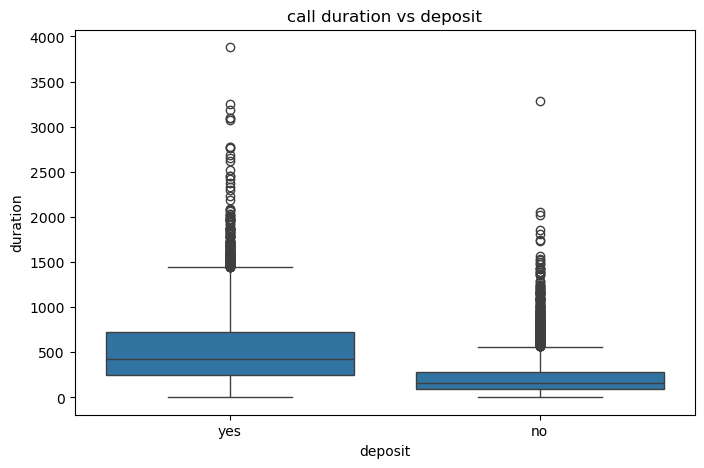

In [44]:
# how much call duration effects of subscription
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="deposit",y="duration")
plt.title("call duration vs deposit")
plt.show()

##### Observation
- Customers who subscribed typically had longer call durations than customers who declined.
- Longer conversations may indicate higher customer engagement and interest.
- However, call duration is only known after the conversation, so it cannot be used for selecting customers before making calls.
- It is valuable for evaluating campaign effectiveness but should not be treated as a predictive variable for customer targeting.

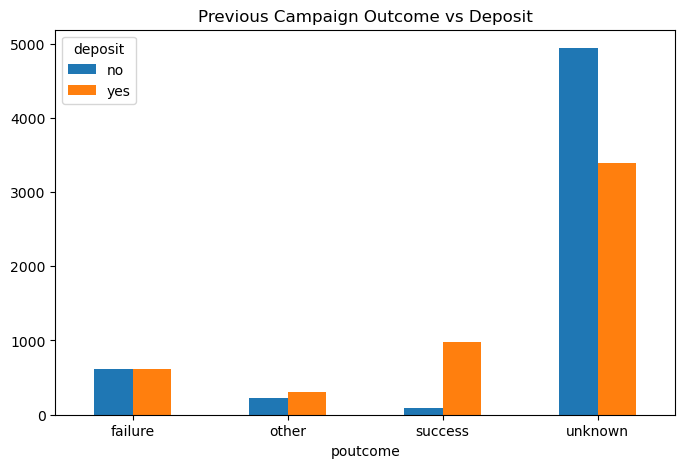

In [45]:
# previous Campaign Outcome vs Deposit
poutcome_dep = pd.crosstab(df["poutcome"], df["deposit"])

poutcome_dep.plot(kind="bar",
                  figsize=(8,5))

plt.title("Previous Campaign Outcome vs Deposit")

plt.xticks(rotation=0)

plt.show()

##### Observation
- Customers whose previous campaign outcome was successful show a much higher likelihood of subscribing again.
- Most records have an unknown previous campaign outcome, suggesting many customers had not participated in earlier campaigns.
- Customers with previous campaign failures rarely subscribe in subsequent campaigns.
- Previous campaign outcome is one of the strongest indicators for identifying promising customers for future marketing efforts.

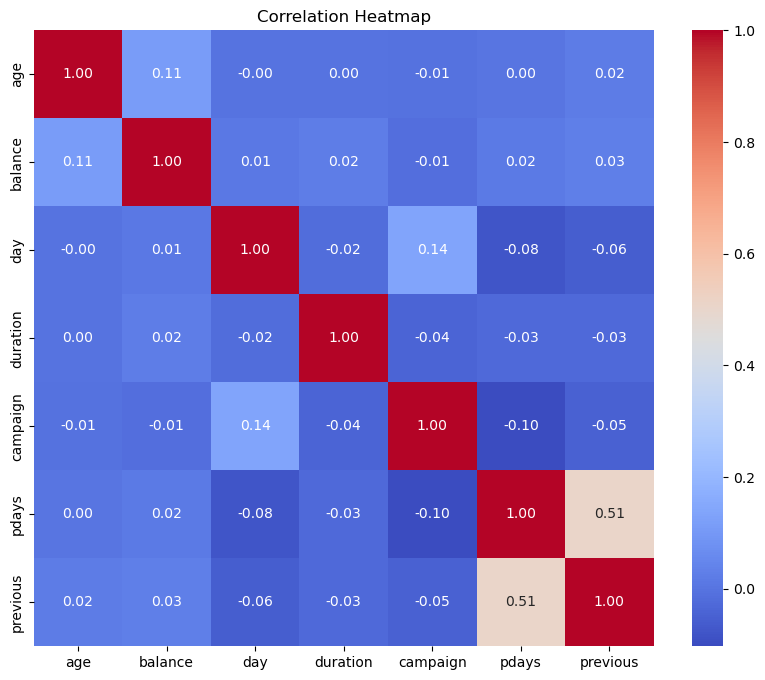

In [46]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

##### Observation
- Most numerical variables exhibit weak correlations, indicating that customer subscription decisions are influenced by multiple factors rather than a single variable.
- A moderate positive correlation exists between pdays and previous, as customers contacted previously tend to have higher values for both features.
- No severe multicollinearity is observed, making the dataset suitable for further statistical analysis or predictive modeling.